<a href="https://colab.research.google.com/github/Abimmmm/Pembelajaran-Mesin-2026/blob/main/Week5/TugasPraktikumWeek5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns; sns.set()

df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# No 1. Seleksi Fitur

X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
# Cek korelasi antar fitur numerik
fitur_numerik = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
df[fitur_numerik].corr()

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


In [12]:
# Bandingkan beberapa kombinasi fitur menggunakan Silhouette Score terbaik (k=2-10)
kandidat = {
    'Income + Spending'      : ['Annual Income (k$)', 'Spending Score (1-100)'],
    'Age + Spending'         : ['Age', 'Spending Score (1-100)'],
    'Age + Income'           : ['Age', 'Annual Income (k$)'],
    'Age + Income + Spending': ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
}

for nama, kolom in kandidat.items():
    skor = {}
    for k in range(2, 11):
        labels_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(df[kolom])
        skor[k] = silhouette_score(df[kolom], labels_k)
    k_terbaik = max(skor, key=skor.get)
    print(f'{nama:25s} -> k terbaik={k_terbaik}; Silhouette={skor[k_terbaik]:.3f}')

Income + Spending         -> k terbaik=5; Silhouette=0.554
Age + Spending            -> k terbaik=4; Silhouette=0.500
Age + Income              -> k terbaik=4; Silhouette=0.434
Age + Income + Spending   -> k terbaik=6; Silhouette=0.452


In [13]:
# Seleksi Fitur
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


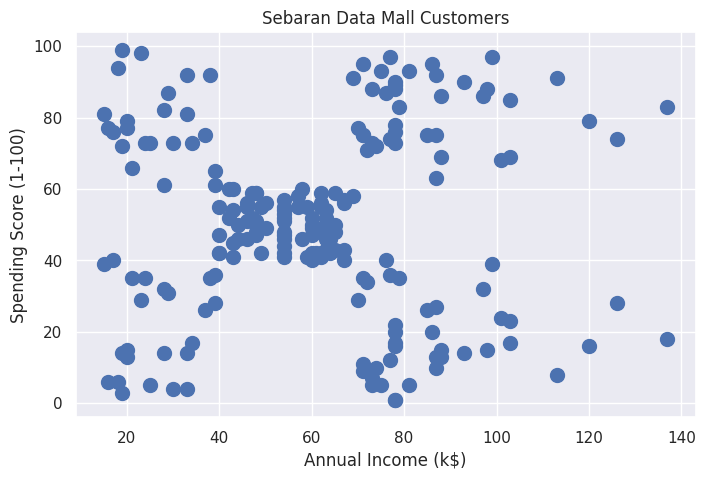

In [14]:
# Plot Data
plt.figure(figsize=(8,5))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Sebaran Data Mall Customers')
plt.show()

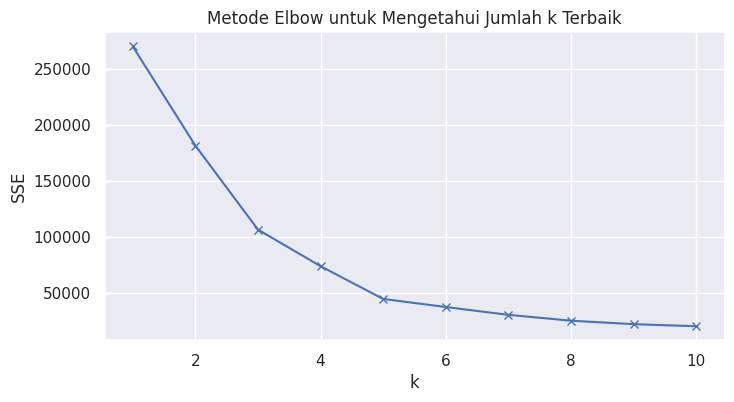

In [15]:
# Implementasi Metode Elbow

# List nilai SSE
sse = []

# Cari k terbaik dari 1-10
K = range(1,11)

# Cek nilai SSE setiap k
for k in K:
 kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
 kmeanModel.fit(X)
 sse.append(kmeanModel.inertia_)


# Plotting the distortions
plt.figure(figsize=(8,4))
plt.plot(K, sse, "bx-")
plt.xlabel("k")
plt.ylabel("SSE")
plt.title("Metode Elbow untuk Mengetahui Jumlah k Terbaik")
plt.show()

In [16]:
# Cek Nilai SSE setiap k
for idx, sse_val in enumerate(sse, start=1):
    print(f'k={idx}; SSE={sse_val}')

k=1; SSE=269981.28000000014
k=2; SSE=181363.59595959607
k=3; SSE=106348.37306211119
k=4; SSE=73679.78903948837
k=5; SSE=44448.45544793369
k=6; SSE=37233.81451071002
k=7; SSE=30241.34361793659
k=8; SSE=25036.417604033977
k=9; SSE=21916.79478984372
k=10; SSE=20072.070939404


In [27]:
cl_kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
y_kmeans = cl_kmeans.fit_predict(X)

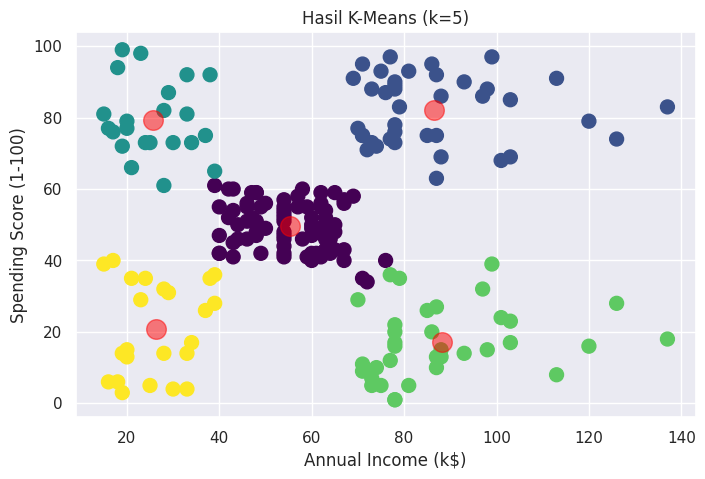

In [18]:
# Plot hasil cluster berdasarkan Annual Income dan Spending Score
plt.figure(figsize=(8,5))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], s = 100, c=y_kmeans, cmap='viridis')

centers = cl_kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.5)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Hasil K-Means (k={k_terbaik})')
plt.show()

In [20]:
# Cek Nilai SSE dan Silhouette Score
print(f'Nilai SSE: {cl_kmeans.inertia_}')
print(f'Silhouette Score: {silhouette_score(X, y_kmeans):.4f}')

Nilai SSE: 44448.45544793369
Silhouette Score: 0.5539


In [19]:
# Profil setiap cluster
df['Cluster'] = y_kmeans

profil = df.groupby('Cluster').agg(
    Jumlah=('CustomerID', 'count'),
    Rata2_Age=('Age', 'mean'),
    Rata2_Income=('Annual Income (k$)', 'mean'),
    Rata2_Spending=('Spending Score (1-100)', 'mean')
).round(2)

profil

,Jumlah,Rata2_Age,Rata2_Income,Rata2_Spending
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


In [29]:
# No 2. Buat dataset make_moons dan normalisasi
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X, labels_true = make_moons(n_samples=1000, noise=0.05, random_state=0)

X = StandardScaler().fit_transform(X)

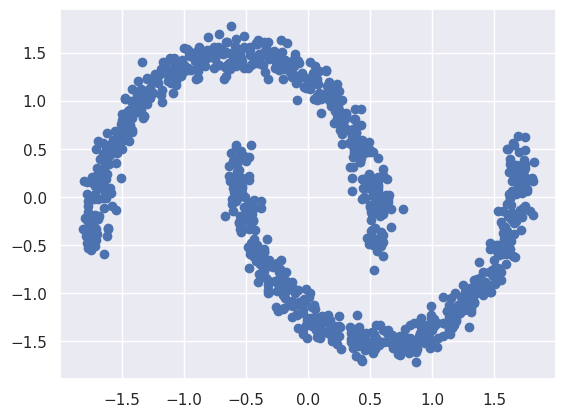

In [22]:
plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [23]:
from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.2, min_samples=5).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 2
Estimated number of noise points: 0


In [24]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.392


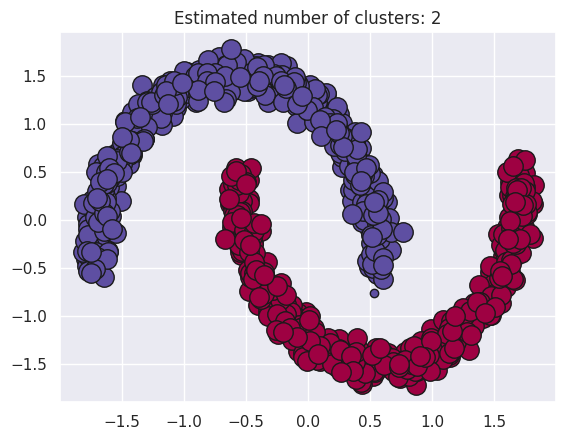

In [25]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

In [30]:
# Eksperimen: eps = 0.05, 0.1, 0.3, 0.5 dan min_samples = 3, 10, 20
eps_list = [0.05, 0.1, 0.3, 0.5]
min_samples_list = [3, 10, 20]

hasil = []
model_eksperimen = {}

for eps in eps_list:
    for ms in min_samples_list:
        db_exp = DBSCAN(eps=eps, min_samples=ms).fit(X)
        lbl = db_exp.labels_
        model_eksperimen[(eps, ms)] = db_exp

        n_clus = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noi = list(lbl).count(-1)

        # Silhouette hanya bisa dihitung jika ada minimal 2 label berbeda
        if len(set(lbl)) >= 2:
            sil_exp = metrics.silhouette_score(X, lbl)
        else:
            sil_exp = np.nan

        hasil.append({
            'eps': eps,
            'min_samples': ms,
            'Klaster': n_clus,
            'Noise': n_noi,
            'Homogeneity': metrics.homogeneity_score(labels_true, lbl),
            'Completeness': metrics.completeness_score(labels_true, lbl),
            'V-measure': metrics.v_measure_score(labels_true, lbl),
            'ARI': metrics.adjusted_rand_score(labels_true, lbl),
            'AMI': metrics.adjusted_mutual_info_score(labels_true, lbl),
            'Silhouette': sil_exp,
        })

df_hasil = pd.DataFrame(hasil).round(3)
df_hasil

,eps,min_samples,Klaster,Noise,Homogeneity,Completeness,V-measure,ARI,AMI,Silhouette
0,0.05,3,67,197,0.804,0.155,0.260,0.033,0.246,0.078
1,0.05,10,0,1000,0.000,1.000,0.000,0.000,0.000,NaN
2,0.05,20,0,1000,0.000,1.000,0.000,0.000,0.000,NaN
3,0.10,3,3,18,0.983,0.708,0.824,0.854,0.823,0.138
4,0.10,10,9,63,0.939,0.358,0.519,0.435,0.517,0.184
5,0.10,20,6,844,0.157,0.153,0.155,0.010,0.152,-0.409
6,0.30,3,2,0,1.000,1.000,1.000,1.000,1.000,0.392
7,0.30,10,2,0,1.000,1.000,1.000,1.000,1.000,0.392
8,0.30,20,2,0,1.000,1.000,1.000,1.000,1.000,0.392
9,0.50,3,1,0,0.000,1.000,0.000,0.000,0.000,NaN


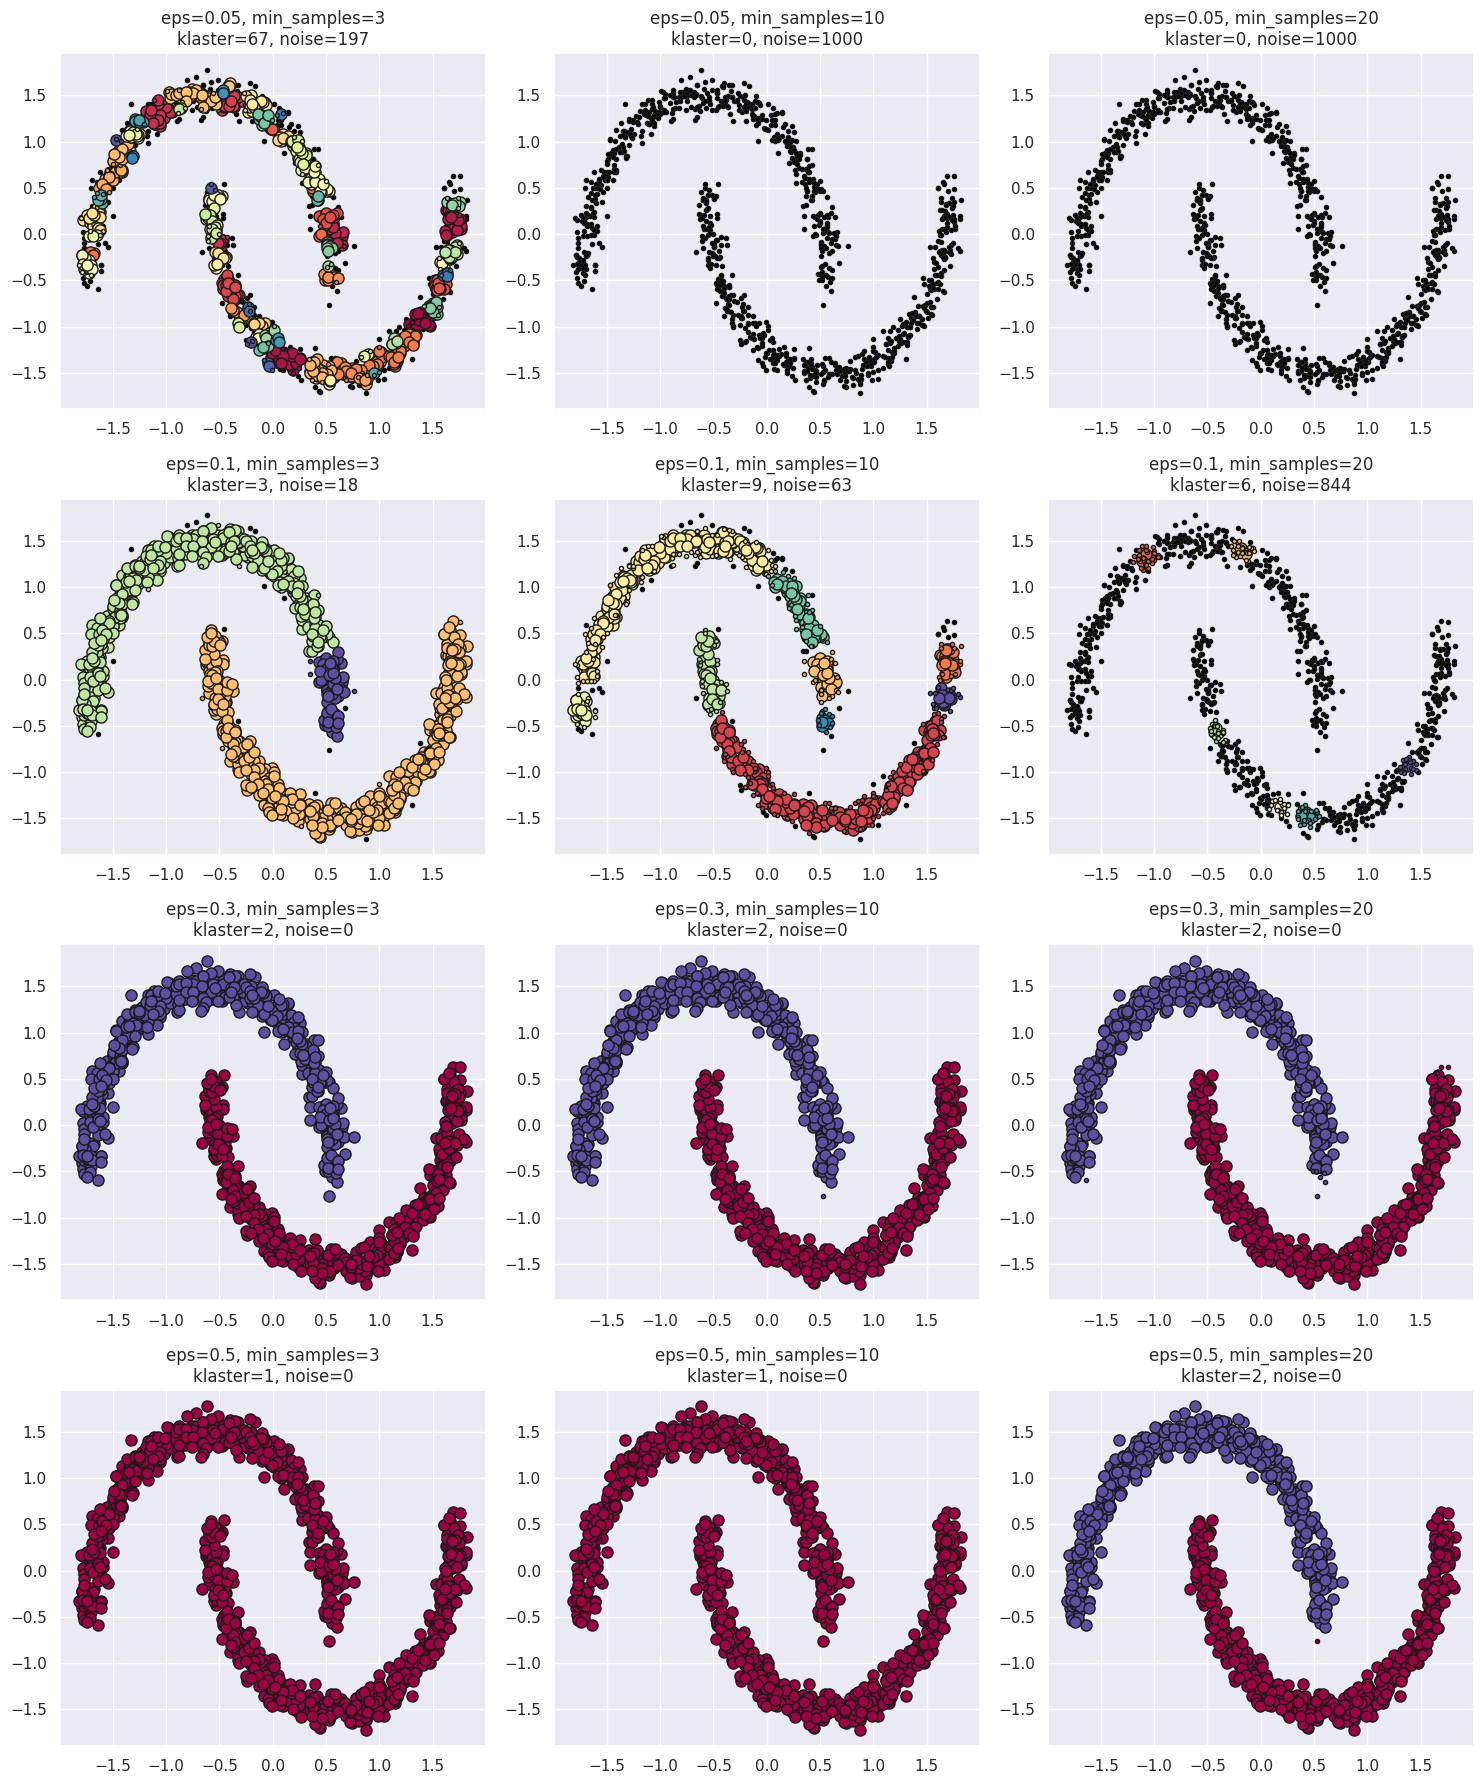

In [31]:
# Visualisasi semua kombinasi (core = besar, non-core = kecil, noise = hitam)
fig, axes = plt.subplots(len(eps_list), len(min_samples_list), figsize=(15, 18))

for i, eps in enumerate(eps_list):
    for j, ms in enumerate(min_samples_list):
        ax = axes[i, j]
        db_exp = model_eksperimen[(eps, ms)]
        lbl = db_exp.labels_

        core_mask = np.zeros_like(lbl, dtype=bool)
        core_mask[db_exp.core_sample_indices_] = True

        uniq = sorted(set(lbl))
        cols = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(uniq))]
        for k, col in zip(uniq, cols):
            if k == -1:
                col = [0, 0, 0, 1]
            member = lbl == k
            xy = X[member & core_mask]
            ax.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col),
                    markeredgecolor="k", markersize=8)
            xy = X[member & ~core_mask]
            ax.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col),
                    markeredgecolor="k", markersize=3)

        n_clus = len(set(lbl)) - (1 if -1 in lbl else 0)
        ax.set_title(f"eps={eps}, min_samples={ms}\nklaster={n_clus}, noise={list(lbl).count(-1)}")

plt.tight_layout()
plt.show()